In [1]:
import torch
import geospaNN
import numpy as np
import pandas as pd
import random
import matplotlib
import matplotlib.pyplot as plt

path = '../data/Output/'

R callback write-console: Loading required package: BRISC
  
R callback write-console: Loading required package: RANN
  
R callback write-console: Loading required package: parallel
  
R callback write-console: Loading required package: rdist
  
R callback write-console: Loading required package: matrixStats
  
R callback write-console: Loading required package: pbapply
  
R callback write-console: The ordering of inputs x (covariates) and y (response) in BRISC_estimation has been changed BRISC 1.0.0 onwards.
  Please check the new documentation with ?BRISC_estimation.
  


R package: BRISC installed


/Users/zhanwentao/miniforge3/envs/Test/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def f1(X): return 10 * np.sin(2 * np.pi * X)
p = 1;
funXY = f1

n = 1000
nn = 20
b = 10

sigma = 5
phi = 0.3
Lambda = 0.01
theta = torch.tensor([sigma, phi / np.sqrt(2), Lambda])

In [3]:
# Simulate data
torch.manual_seed(2025)
X, Y, coord, cov, corerr = geospaNN.Simulation(n, p, nn, funXY, theta, range=[0, b])

/var/folders/lv/q9wzh97j5253zdyp95xsfvgw0000gn/T/ipykernel_8723/1526871050.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  def f1(X): return 10 * np.sin(2 * np.pi * X)


In [4]:
# Preprocess data
random.seed(2024)
X, Y, coord, _ = geospaNN.spatial_order(X, Y, coord, method='max-min')
data = geospaNN.make_graph(X, Y, coord, nn)

np.random.seed(0)
data_train, data_val, data_test = geospaNN.split_data(X, Y, coord, neighbor_size=nn,
                                                      test_proportion=0.2)

In [5]:
# Fit NN
torch.manual_seed(2024)
mlp_nn = torch.nn.Sequential(
    torch.nn.Linear(p, 50),
    torch.nn.ReLU(),
    torch.nn.Linear(50, 20),
    torch.nn.ReLU(),
    torch.nn.Linear(20, 1)
)
nn_model = geospaNN.nn_train(mlp_nn, lr=0.01, min_delta=0.001)
training_log = nn_model.train(data_train, data_val, data_test, seed = 2024)
theta0 = geospaNN.theta_update(mlp_nn(data_train.x).squeeze() - data_train.y,
                               data_train.pos, neighbor_size=20)
model = geospaNN.nngls(p=p, neighbor_size=nn, coord_dimensions=2, mlp=mlp_nn, theta=torch.tensor(theta0))
predict_nn = model.predict(data_train, data_test)

INFO: Early stopping
End at epoch72
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[3.96840929 0.47922617 0.01877751]


In [6]:
# Fit NN-GLS
torch.manual_seed(2024)
mlp_nngls = torch.nn.Sequential(
    torch.nn.Linear(p, 50),
    torch.nn.ReLU(),
    torch.nn.Linear(50, 20),
    torch.nn.ReLU(),
    torch.nn.Linear(20, 1)
)
model_nngls = geospaNN.nngls(p=p, neighbor_size=nn, coord_dimensions=2, mlp=mlp_nngls, theta=torch.tensor(theta0))
nngls_model = geospaNN.nngls_train(model_nngls, lr=0.1, min_delta=0.001)
training_log = nngls_model.train(data_train, data_val, data_test,
                                 Update_init=10, Update_step=5, seed = 2024)
theta_hat = geospaNN.theta_update(mlp_nngls(data_train.x).squeeze() - data_train.y,
                                  data_train.pos, neighbor_size = 20)
model = geospaNN.nngls(p=p, neighbor_size=nn, coord_dimensions=2, mlp=mlp_nngls, theta=torch.tensor(theta_hat))
predict_nngls = model.predict(data_train, data_test)

---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[3.43862246 0.83855585 0.36007767]
to
[3.43862246 0.83855585 0.36007767]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[3.45233698 0.74035013 0.22091169]
to
[3.45233698 0.74035013 0.22091169]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


...

Theta estimated as
[3.93588024 0.5370837  0.0359667 ]
to
[3.93588024 0.5370837  0.0359667 ]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[4.3288701  0.42198069 0.00862316]
to
[4.3288701  0.42198069 0.00862316]
INFO: Early stopping
End at epoch55
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[4.24190624 0.44480095 0.00957582]


In [7]:
# Similar fitting for added-spatial-feature
np.random.seed(0)
data_add_train, data_add_val, data_add_test = geospaNN.split_data(torch.concat([X, coord], axis = 1), Y, coord, neighbor_size=nn,
                                                                  test_proportion=0.2)
torch.manual_seed(2025)
mlp_nn_add = torch.nn.Sequential(
    torch.nn.Linear(p+2, 50),
    torch.nn.ReLU(),
    torch.nn.Linear(50, 20),
    torch.nn.ReLU(),
    torch.nn.Linear(20, 1)
)
nn_add_model = geospaNN.nn_train(mlp_nn_add, lr=0.01, min_delta=0.001)
training_log = nn_add_model.train(data_add_train, data_add_val, data_add_test, seed = 2024)
predict_nn_add = mlp_nn_add(data_add_test.x).detach().numpy().reshape(-1)

In [8]:
# Similar fitting for added-spatial-feature
## Spline generation
K, phi_temp = geospaNN.coord_basis(coord, num_basis = [2 ** 2, 4 ** 2, 6 ** 2])
np.random.seed(0)
data_DK_train, data_DK_val, data_DK_test = geospaNN.split_data(torch.concat([X, phi_temp], axis = 1).float(), 
                                                               Y, coord, neighbor_size=nn, test_proportion=0.2)
                                                               
torch.manual_seed(2024)
mlp_nn_DK = torch.nn.Sequential(
    torch.nn.Linear(p+K, 50),
    torch.nn.ReLU(), 
    torch.nn.Linear(50, 20), 
    torch.nn.ReLU(), 
    torch.nn.Linear(20, 1)) 
nn_DK_model = geospaNN.nn_train(mlp_nn_DK, lr=0.01, min_delta=0.001) 
training_log = nn_DK_model.train(data_DK_train, data_DK_val, data_DK_test, seed = 2024) 
predict_DK = mlp_nn_DK(data_DK_test.x).detach().numpy().reshape(-1)

INFO: Early stopping
End at epoch86


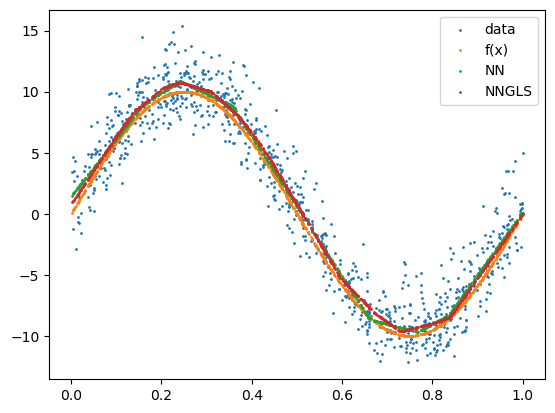

In [9]:
plt.clf()
plt.scatter(X.detach().numpy(), Y.detach().numpy(), s=1, label='data')
plt.scatter(X.detach().numpy(), funXY(X.detach().numpy()), s=1, label='f(x)')
plt.scatter(X.detach().numpy(), mlp_nn(X).detach().numpy(), s=1, label='NN')
plt.scatter(X.detach().numpy(), mlp_nngls(X).detach().numpy(), s=1, label='NNGLS')
plt.legend()
plt.show()

RMSE nn-estimate:  2.96
RMSE nngls:  0.45
RMSE nn+kriging: 0.51
RMSE nn-add-coordinates: 3.17
RMSE nn-spline: 1.97


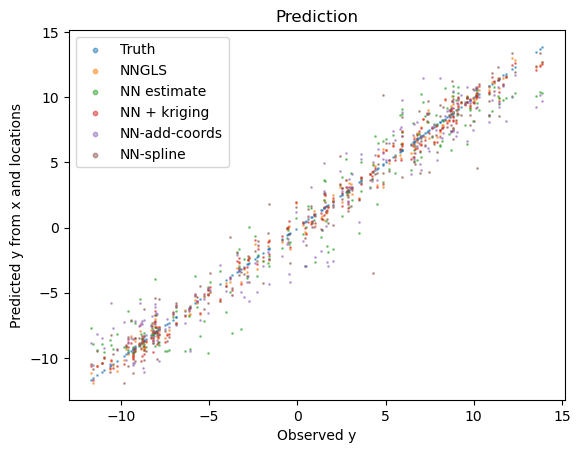

In [10]:
estimate_nn = mlp_nn(data_test.x).detach().numpy().reshape(-1)
plt.clf()
plt.scatter(data_test.y.detach().numpy(), data_test.y.detach().numpy(), s=1, alpha = 0.5, label='Truth')
plt.scatter(data_test.y.detach().numpy(), predict_nngls, s=1, alpha = 0.5, label='NNGLS')
plt.scatter(data_test.y.detach().numpy(), estimate_nn, s=1, alpha = 0.5, label='NN estimate')
plt.scatter(data_test.y.detach().numpy(), predict_nn, s=1, alpha = 0.5, label='NN + kriging')
plt.scatter(data_test.y.detach().numpy(), predict_nn_add, s=1, alpha = 0.5, label='NN-add-coords')
plt.scatter(data_test.y.detach().numpy(), predict_DK, s=1, alpha = 0.5, label='NN-spline')
lgnd = plt.legend(fontsize=10)
plt.xlabel('Observed y', fontsize=10)
plt.ylabel('Predicted y from x and locations', fontsize=10)
plt.title('Prediction')

for handle in lgnd.legend_handles:
    handle.set_sizes([10.0])
plt.savefig(path + 'Prediction.png')

print(f"RMSE nn-estimate:  {torch.mean((data_test.y - estimate_nn)**2):.2f}")
print(f"RMSE nngls:  {torch.mean((data_test.y - predict_nngls)**2):.2f}")
print(f"RMSE nn+kriging: {torch.mean((data_test.y - predict_nn)**2):.2f}")
print(f"RMSE nn-add-coordinates: {torch.mean((data_test.y - predict_nn_add)**2):.2f}")
print(f"RMSE nn-spline: {torch.mean((data_test.y - predict_DK)**2):.2f}")

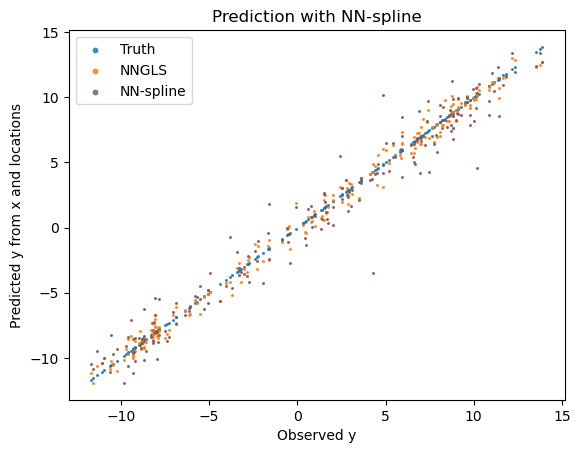

In [11]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
labels = ["Truth", "NNGLS", "NN estimate", "NN + kriging", "NN-add-coords", "NN-spline"]
data = [data_test.y.detach().numpy(), predict_nngls, estimate_nn, predict_nn,  predict_nn_add, predict_DK]

for i, label in enumerate(labels):
    if i <= 1:
        continue
    plt.clf()
    plt.scatter(data_test.y.detach().numpy(), data_test.y.detach().numpy(), s=1.5, alpha = 0.8, label='Truth')
    plt.scatter(data_test.y.detach().numpy(), predict_nngls, s=1.5, alpha = 0.8, label='NNGLS')
    plt.scatter(data_test.y.detach().numpy(), data[i], s=1.5, alpha = 0.8, label=label, color = colors[i])
    #plt.scatter(data_test.y.detach().numpy(), predict3, s=1, alpha = 0.5, label='NNGLS nugget 97%')
    lgnd = plt.legend(fontsize=10)
    plt.xlabel('Observed y', fontsize=10)
    plt.ylabel('Predicted y from x and locations', fontsize=10)
    plt.title('Prediction with ' + label)
    
    for handle in lgnd.legend_handles:
        handle.set_sizes([10.0])
    #plt.show()
    plt.savefig(path + 'Prediction_' + label + '.png')

In [12]:
# Visualize Wendland RBF
## Define the Wendland C2 RBF function
def wendland_c2(r):
    return ((1 - r)**4 * (4 * r + 1)) * (r < 1)

## Define the grid for visualization
x = np.linspace(0, 1, 100)
y = np.linspace(0, 1, 100)
X, Y = np.meshgrid(x, y)

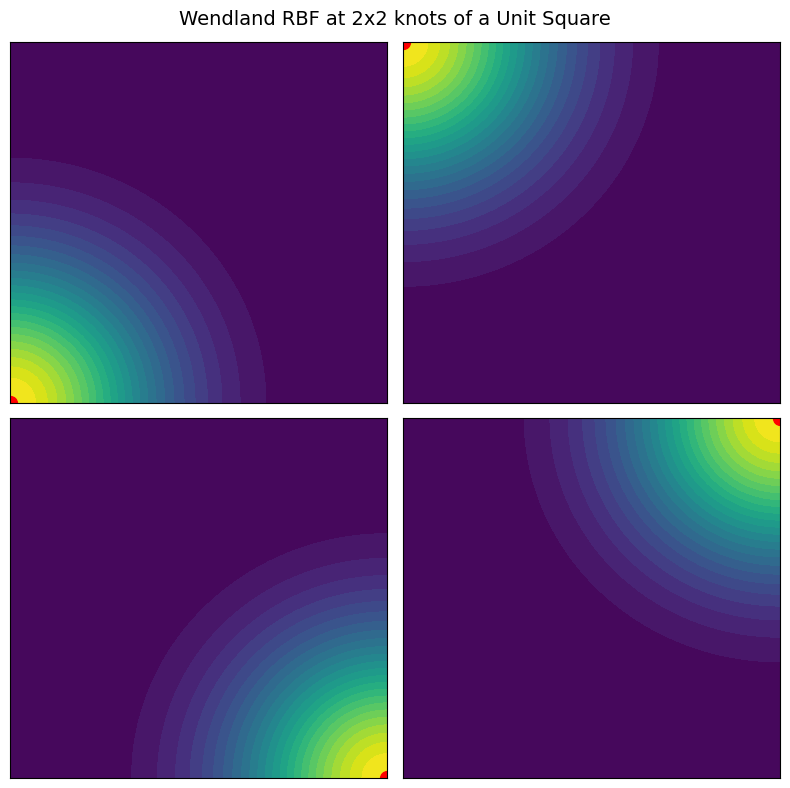

In [13]:
# Define the four knot positions (corners of unit square)
knots = [(0, 0), (0, 1), (1, 0), (1, 1)]

# Create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

# Plot Wendland RBF centered at each knot
for ax, (kx, ky) in zip(axes.flat, knots):
    R = np.sqrt((X - kx)**2 + (Y - ky)**2)  # Compute radial distance
    Z = wendland_c2(R)  # Apply Wendland function

    c = ax.contourf(X, Y, Z, levels=30, cmap='viridis')
    ax.scatter([kx], [ky], color='red', marker='o', s=100, label="Knot")
    #ax.set_title(f"Knot at ({kx}, {ky})")
    ax.set_xticks([])
    ax.set_yticks([])
    #ax.legend()

fig.suptitle("Wendland RBF at 2x2 knots of a Unit Square", fontsize=14)
plt.tight_layout()
#plt.show()
plt.savefig(path + 'Knots_2x2.png')

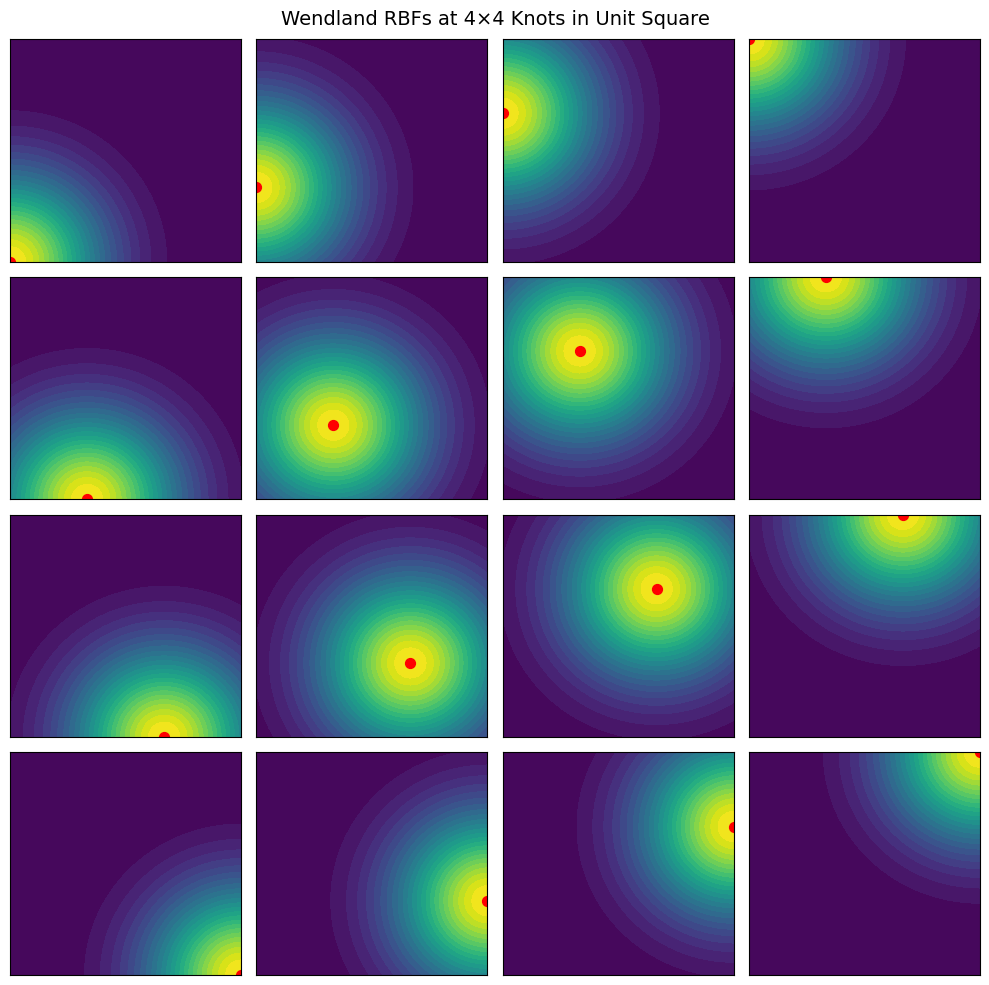

In [14]:
## Define a 4x4 grid of knots within the unit square
num_knots = 4
knot_positions = np.linspace(0, 1, num_knots)
knots = [(kx, ky) for kx in knot_positions for ky in knot_positions]

## Create figure with 4x4 subplots
fig, axes = plt.subplots(num_knots, num_knots, figsize=(10, 10))

## Plot Wendland RBF centered at each knot
for ax, (kx, ky) in zip(axes.flat, knots):
    R = np.sqrt((X - kx)**2 + (Y - ky)**2)  # Compute radial distance
    Z = wendland_c2(R)  # Apply Wendland function

    c = ax.contourf(X, Y, Z, levels=30, cmap='viridis')
    ax.scatter([kx], [ky], color='red', marker='o', s=50, label="Knot")
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("Wendland RBFs at 4×4 Knots in Unit Square", fontsize=14)
plt.tight_layout()
plt.savefig(path + 'Knots_4x4.png')